In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py, math
import numpy as np
import healpy as hp
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy import stats
from tqdm import tqdm

from msfm.utils import files, power_spectra, catalog, observation, diagnostics, files

2026-02-12 07:14:12.390606: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-12 07:14:12.390634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-12 07:14:12.391783: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-12 07:14:12.398660: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 07:14:13.743293: W tensorflow/compiler/tf2

In [2]:
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml"
conf = files.load_config(conf)

n_pix = conf["analysis"]["n_pix"]
apply_norm = False

# metacal_mask = files.get_tomo_masks(conf, nest_out=False)["metacal"].astype(bool)
metacal_mask = files.get_tomo_masks(conf, nest_out=False)["metacal"].astype(bool)[:,0]

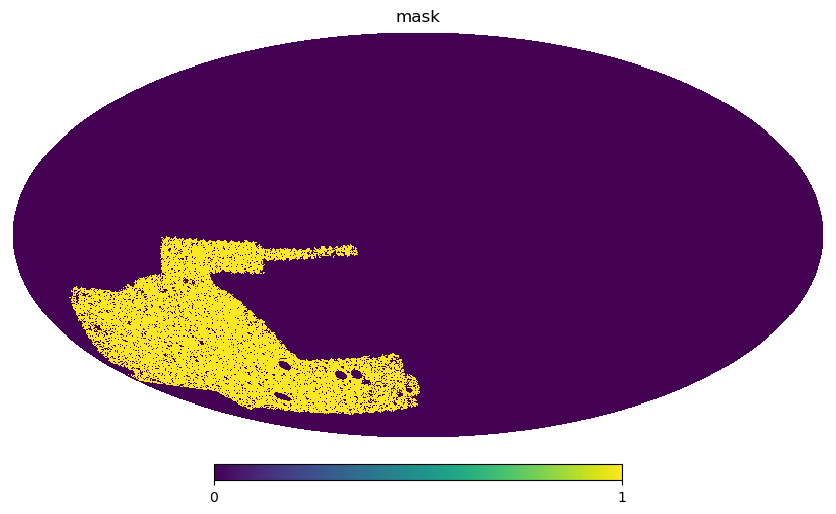

In [3]:
iz = 0
hp.mollview(metacal_mask, title="mask")
# hp.mollview(metacal_mask[:,iz], title="mask")

# DES

In [5]:
des_gamma_map, des_count_map = catalog.build_metacal_map_from_cat(conf)

des_gamma_map *= metacal_mask[:,np.newaxis,np.newaxis]
des_count_map *= metacal_mask[:,np.newaxis]

26-02-12 07:15:35   catalog.py WAR   Compare with Table 1 in https://arxiv.org/pdf/2105.13543 
26-02-12 07:15:35   catalog.py INF   Metacalibration bin 1 
26-02-12 07:15:35   catalog.py INF   N_gal = 24940465, n_eff = 1.476 [arcmin^-2] 
26-02-12 07:15:35   catalog.py INF   mean(e1) = 3.22e-04, mean(e2) = 1.60e-04 
26-02-12 07:15:36   catalog.py INF   sigma_e (H12) = 0.245, sigma_e (C13) = 0.187 
26-02-12 07:15:37   catalog.py INF   mean(R_gamma) = 0.7636 
26-02-12 07:15:37   catalog.py INF   z_mean (DNF) = 0.3305 
26-02-12 07:15:43   catalog.py INF   Metacalibration bin 2 
26-02-12 07:15:43   catalog.py INF   N_gal = 25280405, n_eff = 1.479 [arcmin^-2] 
26-02-12 07:15:43   catalog.py INF   mean(e1) = 3.36e-04, mean(e2) = 3.74e-05 
26-02-12 07:15:44   catalog.py INF   sigma_e (H12) = 0.265, sigma_e (C13) = 0.191 
26-02-12 07:15:45   catalog.py INF   mean(R_gamma) = 0.7182 
26-02-12 07:15:45   catalog.py INF   z_mean (DNF) = 0.5133 
26-02-12 07:15:51   catalog.py INF   Metacalibration bi

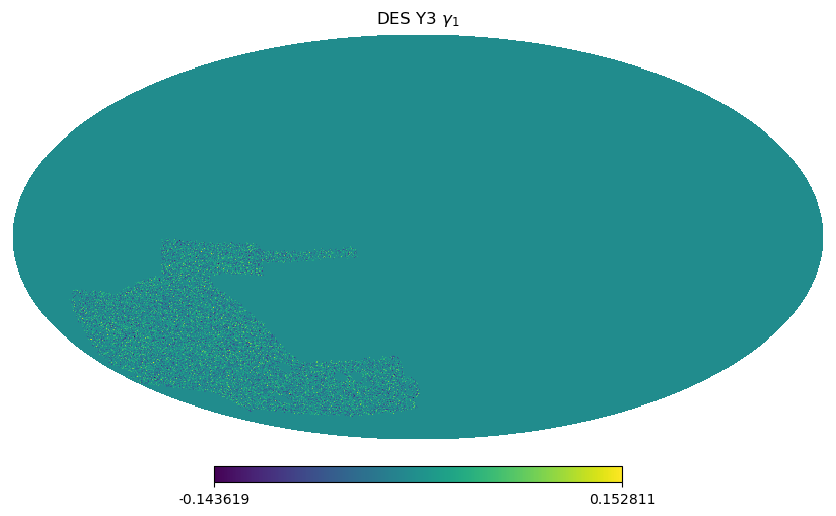

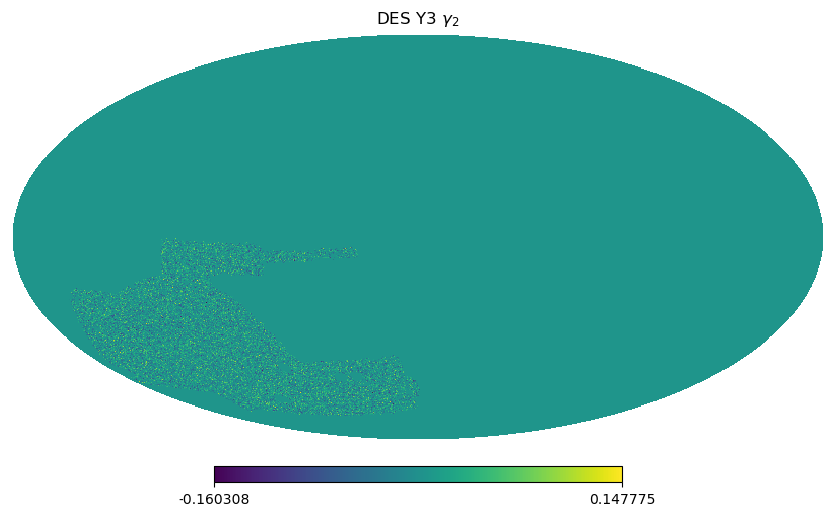

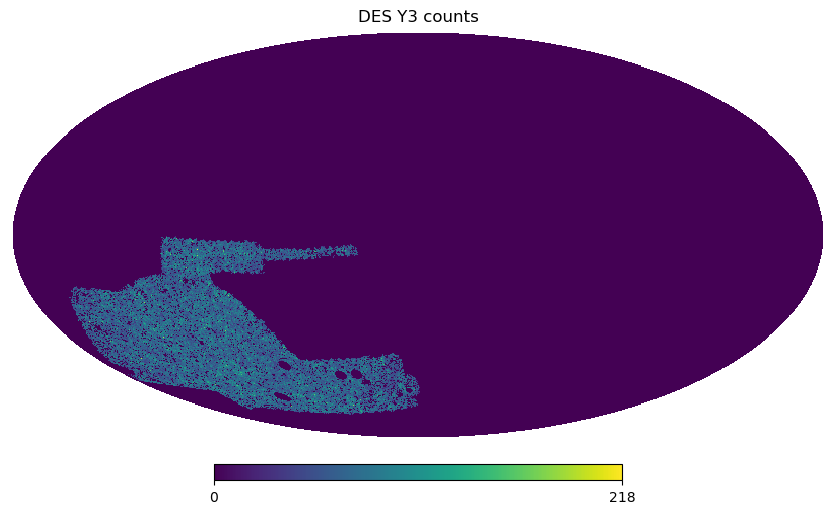

In [6]:
hp.mollview(des_gamma_map[:,iz,0], title=r"DES Y3 $\gamma_1$")
hp.mollview(des_gamma_map[:,iz,1], title=r"DES Y3 $\gamma_2$")
hp.mollview(des_count_map[:,iz], title="DES Y3 counts")

# shape noise

In [7]:
sn_gamma_map = observation.make_shape_noise_map(des_count_map, conf)

26-02-12 07:16:07     files.py INF   Loaded the noise file 


2026-02-12 07:16:08.560285: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0


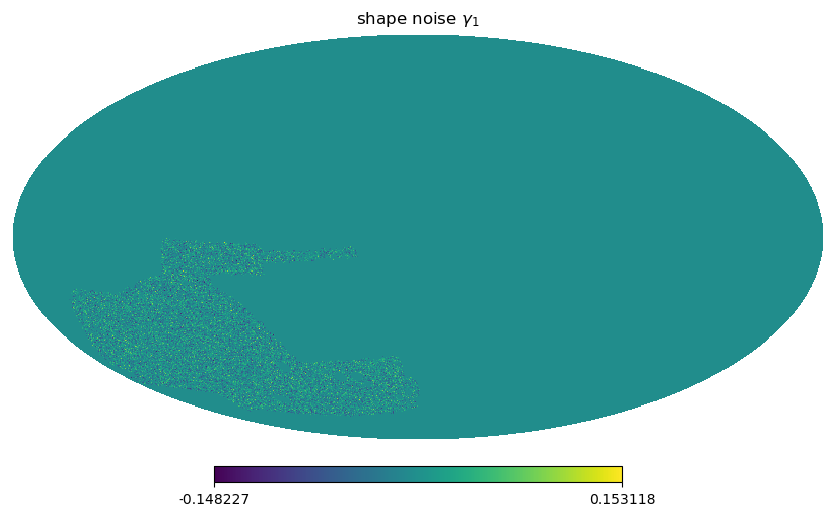

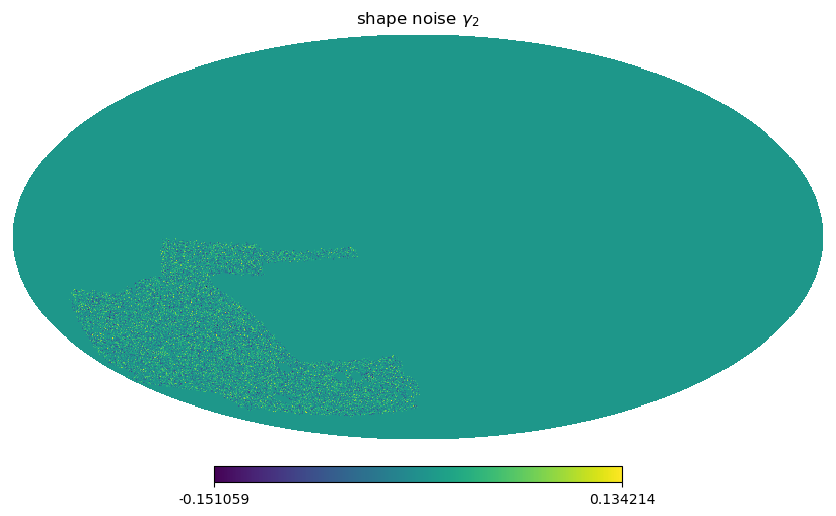

In [8]:
hp.mollview(sn_gamma_map[:,iz,0], title=r"shape noise $\gamma_1$")
hp.mollview(sn_gamma_map[:,iz,1], title=r"shape noise $\gamma_2$")

# diagnostics

In [9]:
des_gamma_fp = des_gamma_map[metacal_mask]
sn_gamma_fp = sn_gamma_map[metacal_mask]

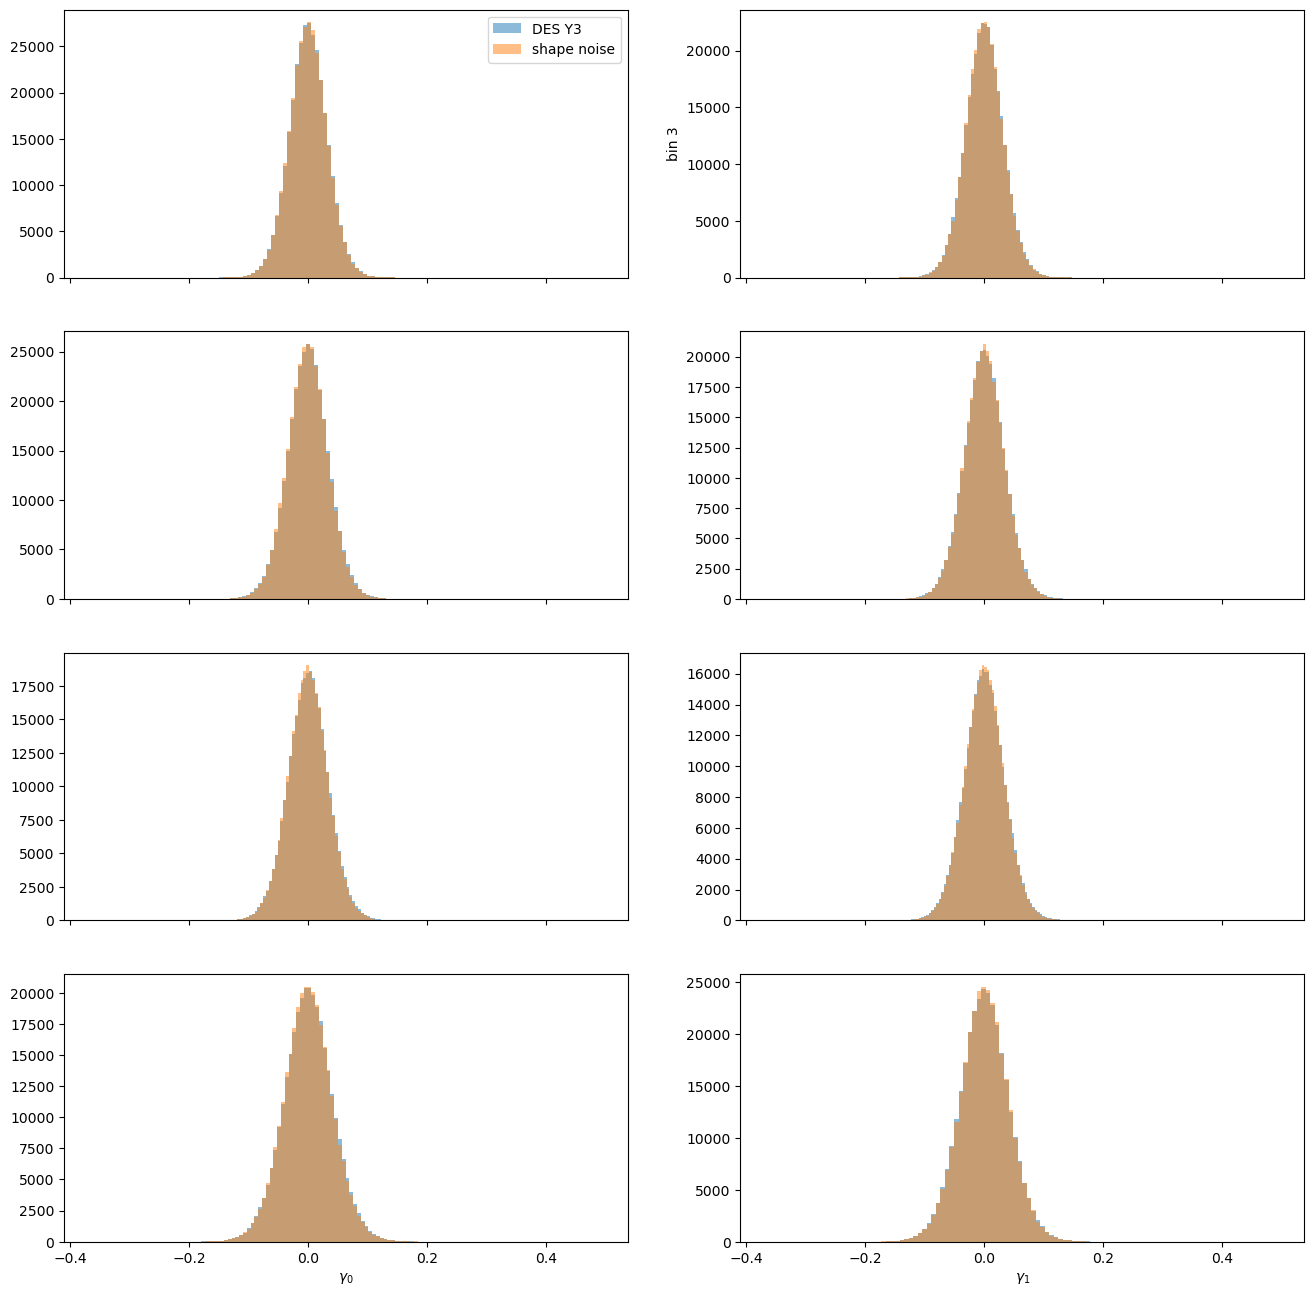

In [10]:
n_z = 4
q_low = 0.01
q_high = 0.99

nrows = n_z
ncols = 2
fig, ax = plt.subplots(figsize=(8*ncols, 4*nrows), nrows=nrows, ncols=ncols, sharex=True)

for i in range(nrows):
    ax[0,1].set(ylabel=f"bin {i}")
    
    for j in range(ncols):
        des = des_gamma_fp[:,i,j]
        sn = sn_gamma_fp[:,i,j]

        # # consistently filter out extremes
        # # low, high = np.quantile(des, q_low), np.quantile(des, q_high) 
        # low, high = np.quantile(sn, q_low), np.quantile(sn, q_high) 
        # des = des[(low < des) & (des < high)]
        # sn = sn[(low < sn) & (sn < high)]
        
        _, bins = np.histogram(des, bins=100)      
        ax[i,j].hist(des, bins, label="DES Y3", color="tab:blue", alpha=0.5)
        ax[i,j].hist(sn, bins, label="shape noise", color="tab:orange", alpha=0.5)

ax[0,0].legend()

for j in range(ncols):
    ax[-1,j].set(xlabel=r"$\gamma_" + str(j) + r"$")